In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'z'}

In [3]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_z
['reference', 'info.json', 'target']


In [4]:
TARGET_VAR = 'roll'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(DYNAMIC_LIMITS)
print(STATIC_LIMITS)

{'dynamic': [20, 200], 'static': [200, 300]}
[20, 200]
[200, 300]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,wz,tmp,pitch,e,ay,ax,wx,wy,time,az,roll,yaw
0,10042,52.5,-2622,-0.468,-42901,26431,-15636,-22949,2.384186e-07,994242,-1376,2397
1,10042,52.5,-2622,-0.468,-42901,26431,-15636,-22949,1.046014e-02,994242,-1376,2397
2,10222,52.7,-2614,-0.468,-47039,21619,-22750,-13719,1.129909e-01,996295,-1380,2423
3,-2886,52.7,-2620,-0.468,-45700,26012,-35211,-31133,2.098117e-01,999438,-1380,2432
4,2990,52.8,-2617,-0.468,-46382,25747,-6358,22587,3.180597e-01,994622,-1378,2438
...,...,...,...,...,...,...,...,...,...,...,...,...
3049,34041,55.4,-2514,-1.692,-42952,22450,5797,-1749,3.048170e+02,999315,-1372,5319
3050,11482,55.5,-2513,-1.692,-40155,20142,22791,-12709,3.049235e+02,995040,-1373,5320
3051,30647,55.5,-2515,-1.692,-44439,24789,-39247,-2397,3.050194e+02,998141,-1371,5320
3052,-6663,55.6,-2517,-1.692,-42861,23058,1214,-44996,3.051234e+02,998350,-1369,5321


- Convertendo pra radianos

In [6]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,wz,tmp,pitch,e,ay,ax,wx,wy,time,az,roll,yaw
0,0.10042,52.5,-2.622,-0.468,-0.420715,0.259200,-0.15636,-0.22949,2.384186e-07,9.750183,-1.376,2.397
1,0.10042,52.5,-2.622,-0.468,-0.420715,0.259200,-0.15636,-0.22949,1.046014e-02,9.750183,-1.376,2.397
2,0.10222,52.7,-2.614,-0.468,-0.461295,0.212010,-0.22750,-0.13719,1.129909e-01,9.770316,-1.380,2.423
3,-0.02886,52.7,-2.620,-0.468,-0.448164,0.255091,-0.35211,-0.31133,2.098117e-01,9.801139,-1.380,2.432
4,0.02990,52.8,-2.617,-0.468,-0.454852,0.252492,-0.06358,0.22587,3.180597e-01,9.753910,-1.378,2.438


- Formatando as colunas pra ficar igual a de referência

In [7]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,wz,tmp,pitch,e,ay,ax,wx,wy,time,az,roll,yaw
0,-0.22949,52.5,1.376,-0.468,9.750183,0.259200,-0.15636,-0.10042,2.384186e-07,-0.420715,-2.622,2.397
1,-0.22949,52.5,1.376,-0.468,9.750183,0.259200,-0.15636,-0.10042,1.046014e-02,-0.420715,-2.622,2.397
2,-0.13719,52.7,1.380,-0.468,9.770316,0.212010,-0.22750,-0.10222,1.129909e-01,-0.461295,-2.614,2.423
3,-0.31133,52.7,1.380,-0.468,9.801139,0.255091,-0.35211,0.02886,2.098117e-01,-0.448164,-2.620,2.432
4,0.22587,52.8,1.378,-0.468,9.753910,0.252492,-0.06358,-0.02990,3.180597e-01,-0.454852,-2.617,2.438


In [8]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,wz,tmp,pitch,e,ay,ax,wx,wy,time,az,roll,yaw


# VISUALIZAÇÃO DE VARIÁVEIS

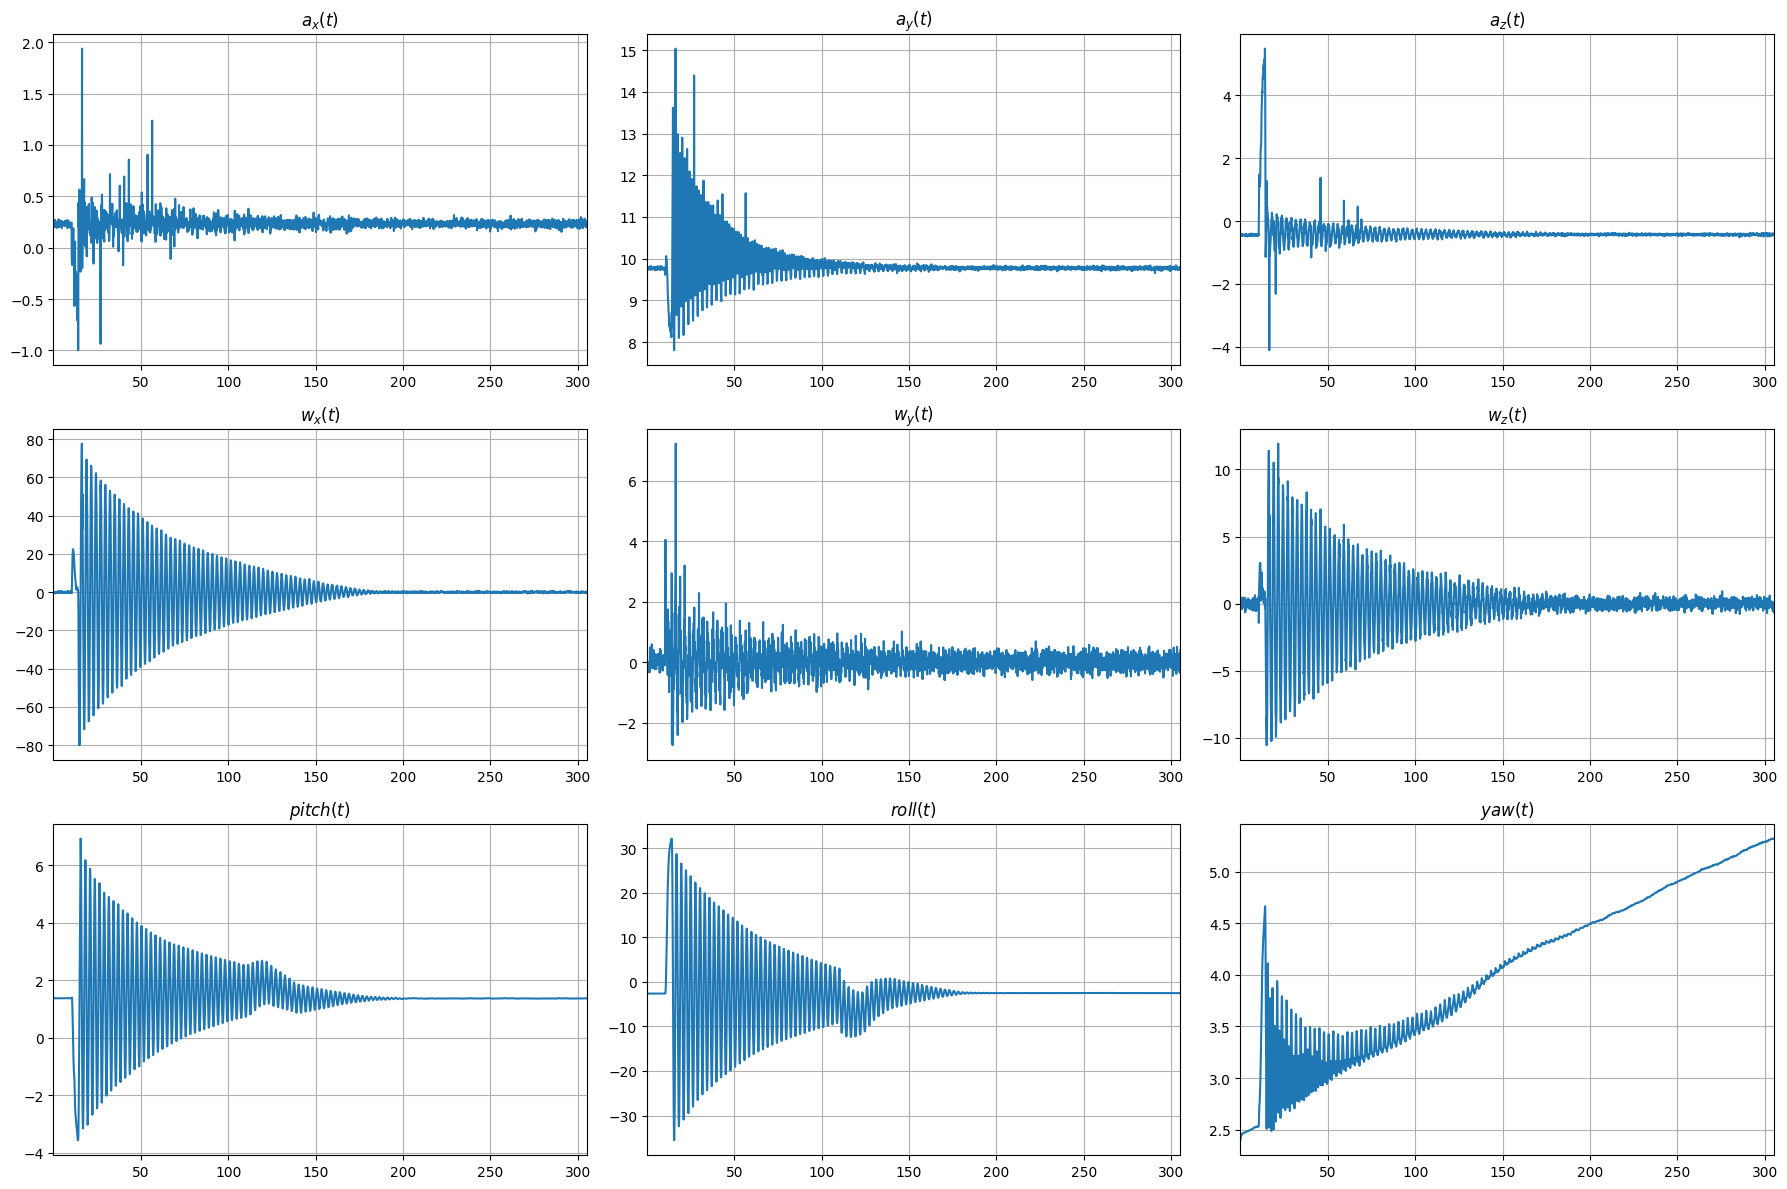

In [9]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

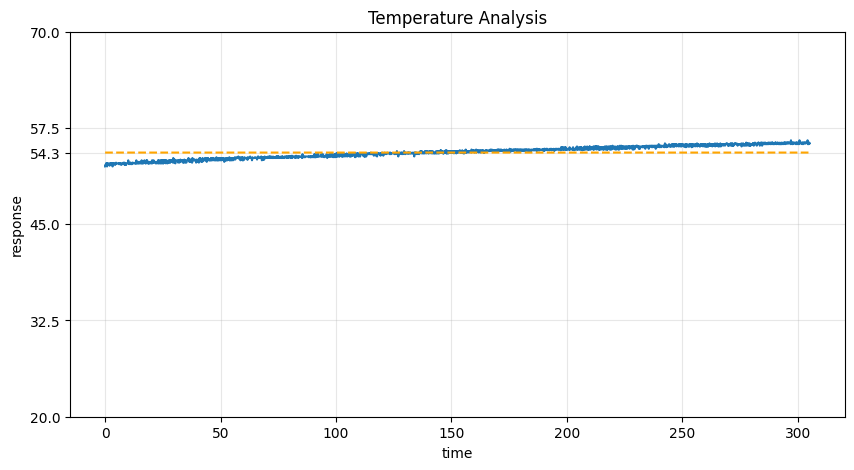

In [10]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

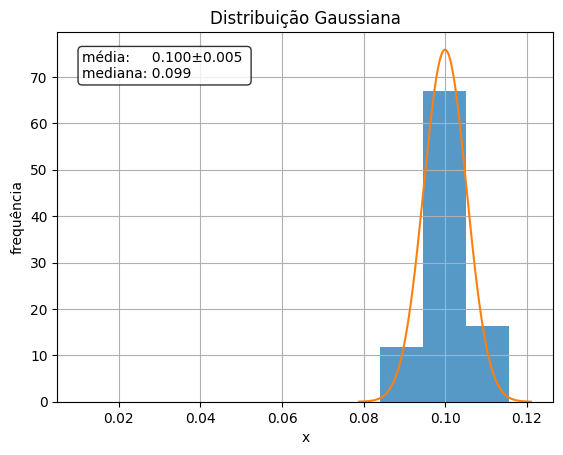

,time,wz,tmp,pitch,e,ay,ax,wx,wy,az,roll,yaw
0,0.0,-0.22949,52.5,1.376,-0.468,9.750183,0.259200,-0.15636,-0.10042,-0.420715,-2.622,2.397
1,0.1,-0.22949,52.5,1.376,-0.468,9.750183,0.259200,-0.15636,-0.10042,-0.420715,-2.622,2.397
2,0.2,-0.13719,52.7,1.380,-0.468,9.770316,0.212010,-0.22750,-0.10222,-0.461295,-2.614,2.423
3,0.3,-0.31133,52.7,1.380,-0.468,9.801139,0.255091,-0.35211,0.02886,-0.448164,-2.620,2.432
4,0.4,0.22587,52.8,1.378,-0.468,9.753910,0.252492,-0.06358,-0.02990,-0.454852,-2.617,2.438
...,...,...,...,...,...,...,...,...,...,...,...,...
3049,304.9,-0.01749,55.4,1.372,-1.692,9.799932,0.220159,0.05797,-0.34041,-0.421215,-2.514,5.319
3050,305.0,-0.12709,55.5,1.373,-1.692,9.758009,0.197526,0.22791,-0.11482,-0.393786,-2.513,5.320
3051,305.1,-0.02397,55.5,1.371,-1.692,9.788419,0.243097,-0.39247,-0.30647,-0.435798,-2.515,5.320
3052,305.2,-0.44996,55.6,1.369,-1.692,9.790469,0.226122,0.01214,0.06663,-0.420323,-2.517,5.321


In [11]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [12]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [13]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,wz,tmp,pitch,e,ay,ax,wx,wy,az,roll,yaw,static
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True
2797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True
2798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True
2799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True


# FILTRANDO POR VARIAVEL

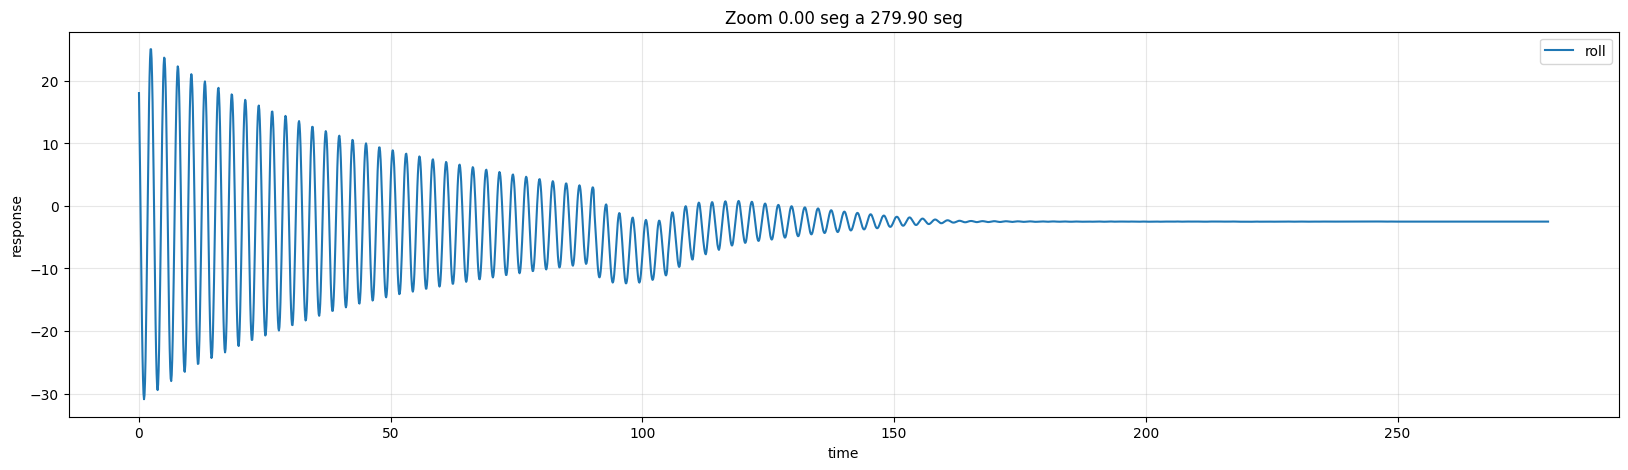

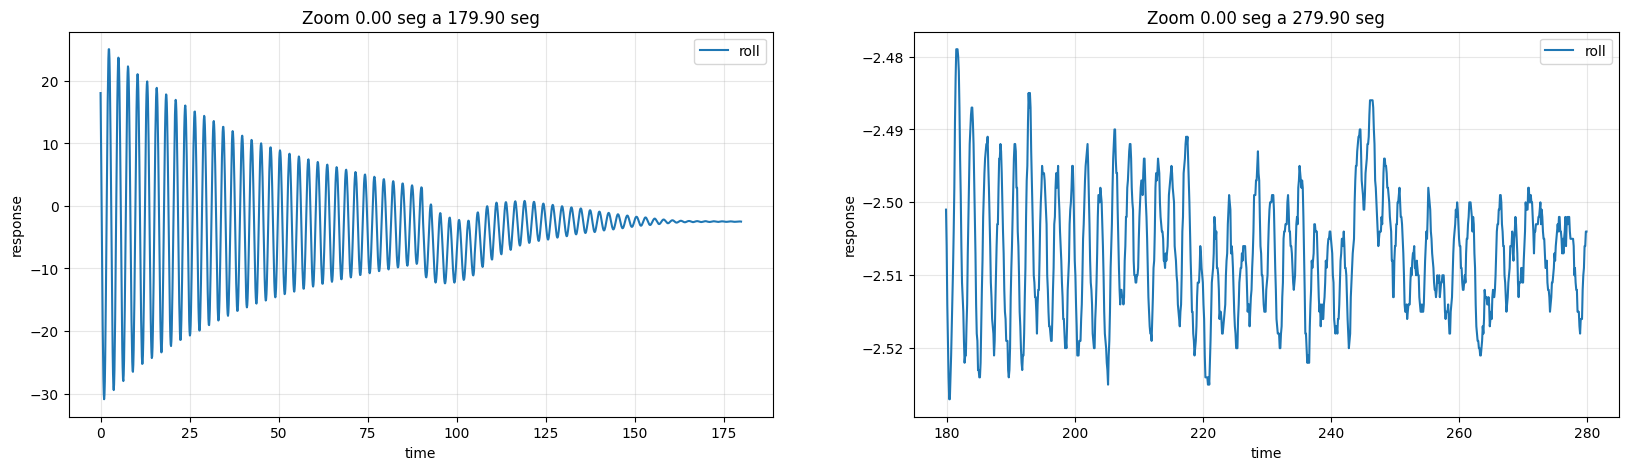

In [14]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [15]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True
2797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True
2798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True
2799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True


In [16]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)